In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import os
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

from euroleague_api.boxscore_data import BoxScoreData

competition_code = "E"
season = 2025           

boxscore = BoxScoreData(competition_code)

/home/chrispetr/personal_projects/euroleague_api_notebooks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dfseason=boxscore.get_player_boxscore_stats_single_season(season)

Season 2025: 100%|██████████| 320/320 [01:04<00:00,  4.95it/s]


In [4]:
# Load your mapping CSV file that contains the player IDs and their corresponding positions
mapped_positions = pd.read_csv("data/mappings/euroleague_players_to_map.csv")

# Keep only the ID and Position columns
positions_only = mapped_positions[['Player_ID', 'Position']]

# Merge the positions into your main dataframe using a 'left' merge
dfseason = dfseason.merge(positions_only, on='Player_ID', how='left')

# Quick sanity check: Are there any real players missing a position?
missing_pos_mask = dfseason['Position'].isna() & ~dfseason['Player_ID'].isin(['Team', 'Total'])
unmapped_players = dfseason[missing_pos_mask]['Player'].unique()

if len(unmapped_players) > 0:
    print(f"Found {len(unmapped_players)} players in dfseason without a mapped position:")
    print(unmapped_players)
else:
    print("Merge successful! Every player in dfseason now has a position assigned.")

# Save the local backup of the merged dataframe to a CSV file with a dynamic name based on the latest round number

# Get the latest round number from the dataframe (ensure it's treated as a number/string properly)
latest_round = dfseason['Round'].max()

# Create the dynamic filename
save_filename = f"data/player_data_R{latest_round}.csv"

# Save the merged dataframe to CSV (index=False prevents adding an unnamed numbering column)
dfseason.to_csv(save_filename, index=False)

print(f"Success! Data backed up locally as: '{save_filename}'")

Found 3 players in dfseason without a mapped position:
['LESSORT, MATHIAS' 'EBO, AMIT' 'RANDOLPH, LEVI']
Success! Data backed up locally as: 'data/player_data_R34.csv'


In [5]:
# Preparation for advanced stats calculations
# Create a working copy so the original dfseason remains completely untouched
df_prep = dfseason.copy()

# Drop these columns if they already exist (prevents errors if you run this cell twice!)
df_prep = df_prep.drop(columns=['Opponent', 'Home_Away', 'Position_Group'], errors='ignore')

# Find the opposing team for every player in every game
game_teams = df_prep[['Gamecode', 'Team']].drop_duplicates()
opponents = game_teams.merge(game_teams, on='Gamecode', suffixes=('', '_Opp'))
opponents = opponents[opponents['Team'] != opponents['Team_Opp']].rename(columns={'Team_Opp': 'Opponent'})

# Merge the Opponent column into the working dataframe
df_prep = df_prep.merge(opponents, on=['Gamecode', 'Team'], how='left')

# Handle the 'Home' column
if df_prep['Home'].dtype == bool or set(df_prep['Home'].dropna().unique()).issubset({0, 1}):
    df_prep['Home_Away'] = np.where(df_prep['Home'], 'Home', 'Away')
else:
    df_prep['Home_Away'] = np.where(df_prep['Team'] == df_prep['Home'], 'Home', 'Away')

# Add grouped positions (Guard, Forward, Center)
pos_mapping = {'PG': 'Guard', 'SG': 'Guard', 'SF': 'Forward', 'PF': 'Forward', 'C': 'Center'}
df_prep['Position_Group'] = df_prep['Position'].map(pos_mapping)

# The advaced stats calculations are a bit complex, so we'll put them in a function to keep things organized and reusable for different splits (Season, L3, L5, L8)
def calculate_advanced_stats(df, split_name, n_games=None):
    df_scored = df.copy()
    df_allowed = df.copy()
    
    # Scored is tied to the Player's Team
    df_scored['Focus_Team'] = df_scored['Team']
    df_scored['Focus_Location'] = df_scored['Home_Away']
    
    # Allowed is tied to the Opponent's perspective
    df_allowed['Focus_Team'] = df_allowed['Opponent']
    df_allowed['Focus_Location'] = df_allowed['Home_Away'].apply(lambda x: 'Away' if x == 'Home' else 'Home')
    
    # --- Filter for Last N Games ---
    if n_games:
        # Scored Rank (Offense)
        r_scored = df_scored[['Team', 'Focus_Location', 'Round']].drop_duplicates()
        r_scored['Rank'] = r_scored.groupby(['Team', 'Focus_Location'])['Round'].rank(method='first', ascending=False)
        df_scored = df_scored.merge(r_scored[r_scored['Rank'] <= n_games], on=['Team', 'Focus_Location', 'Round'])
        
        # Allowed Rank (Defense)
        r_allowed = df_allowed[['Focus_Team', 'Focus_Location', 'Round']].drop_duplicates()
        r_allowed['Rank'] = r_allowed.groupby(['Focus_Team', 'Focus_Location'])['Round'].rank(method='first', ascending=False)
        df_allowed = df_allowed.merge(r_allowed[r_allowed['Rank'] <= n_games], on=['Focus_Team', 'Focus_Location', 'Round'])

    # Duplicate the scored data and tag it as 'All'
    df_scored_all = df_scored.copy()
    df_scored_all['Focus_Location'] = 'All'
    df_scored = pd.concat([df_scored, df_scored_all], ignore_index=True)
    
    # Duplicate the allowed data and tag it as 'All'
    df_allowed_all = df_allowed.copy()
    df_allowed_all['Focus_Location'] = 'All'
    df_allowed = pd.concat([df_allowed, df_allowed_all], ignore_index=True)
    # ===================================================

    # 1. Total Valuation Scored
    game_scored = df_scored.groupby(['Focus_Team', 'Focus_Location', 'Round'])['Valuation'].sum().reset_index()
    avg_scored = game_scored.groupby(['Focus_Team', 'Focus_Location'])['Valuation'].mean().reset_index()
    avg_scored.rename(columns={'Valuation': 'PIR_Scored'}, inplace=True)
    
    # 2. Total Valuation Allowed
    game_allowed = df_allowed.groupby(['Focus_Team', 'Focus_Location', 'Round'])['Valuation'].sum().reset_index()
    avg_allowed = game_allowed.groupby(['Focus_Team', 'Focus_Location'])['Valuation'].mean().reset_index()
    avg_allowed.rename(columns={'Valuation': 'PIR_Allowed'}, inplace=True)
    
    # 3. Valuation Allowed by Specific Position (PG, SG, etc.)
    game_pos_allow = df_allowed.groupby(['Focus_Team', 'Focus_Location', 'Round', 'Position'])['Valuation'].sum().reset_index()
    avg_pos_allow = game_pos_allow.groupby(['Focus_Team', 'Focus_Location', 'Position'])['Valuation'].mean().unstack(fill_value=0).reset_index()
    avg_pos_allow.columns = [f"Allow_{c}" if c not in ['Focus_Team', 'Focus_Location'] else c for c in avg_pos_allow.columns]
    
    # 4. Valuation Allowed by Position Group (Guard, Forward, Center)
    game_grp_allow = df_allowed.groupby(['Focus_Team', 'Focus_Location', 'Round', 'Position_Group'])['Valuation'].sum().reset_index()
    avg_grp_allow = game_grp_allow.groupby(['Focus_Team', 'Focus_Location', 'Position_Group'])['Valuation'].mean().unstack(fill_value=0).reset_index()
    avg_grp_allow.columns = [f"Allow_{c}" if c not in ['Focus_Team', 'Focus_Location'] else c for c in avg_grp_allow.columns]

    # --- Merge Everything ---
    master = avg_scored.merge(avg_allowed, on=['Focus_Team', 'Focus_Location'], how='outer')
    master = master.merge(avg_pos_allow, on=['Focus_Team', 'Focus_Location'], how='outer')
    master = master.merge(avg_grp_allow, on=['Focus_Team', 'Focus_Location'], how='outer')
    
    master.insert(2, 'Split', split_name)
    return master

# Run the splits and export to CSV
print("Calculating Season, L3, L5, and L8 Averages...")

clean_df = df_prep.dropna(subset=['Position'])

df_season = calculate_advanced_stats(clean_df, 'Season', n_games=None)
df_l3 = calculate_advanced_stats(clean_df, 'L3', n_games=3)
df_l5 = calculate_advanced_stats(clean_df, 'L5', n_games=5)
df_l8 = calculate_advanced_stats(clean_df, 'L8', n_games=8)

# Combine everything
final_analysis = pd.concat([df_season, df_l3, df_l5, df_l8], ignore_index=True)

# Sort logically for viewing (Team -> Split -> Location)
split_order = {'Season': 1, 'L8': 2, 'L5': 3, 'L3': 4}
loc_order = {'All': 1, 'Home': 2, 'Away': 3}

final_analysis['Split_Sort'] = final_analysis['Split'].map(split_order)
final_analysis['Loc_Sort'] = final_analysis['Focus_Location'].map(loc_order)

final_analysis = final_analysis.sort_values(
    by=['Focus_Team', 'Split_Sort', 'Loc_Sort']
).drop(columns=['Split_Sort', 'Loc_Sort'])

# Round to 2 decimal places and clean NA values
final_analysis = final_analysis.fillna(0).round(2)

# Save to CSV
final_analysis.to_csv("data/PIR_Team_Analysis.csv", index=False)

print("Analysis Complete! File saved as 'PIR_Team_Analysis.csv'.")

Calculating Season, L3, L5, and L8 Averages...
Analysis Complete! File saved as 'PIR_Team_Analysis.csv'.


In [6]:
# Configuration for the heatmap function and team logos
LOGO_DIR = "team_logos/" 
TARGET_LOGO_HEIGHT = 27  

def get_team_logo(team_abbr, target_height=TARGET_LOGO_HEIGHT):
    """Loads a logo, forces RGBA to prevent color glitches, and scales it."""
    logo_path = os.path.join(LOGO_DIR, f"{team_abbr}.png")
    if not os.path.exists(logo_path): return None 
        
    # The RGBA fix for indexed images (ex. Real Madrid)
    img = Image.open(logo_path).convert("RGBA")
    
    aspect_ratio = img.width / img.height
    new_width = int(target_height * aspect_ratio)
    img = img.resize((new_width, target_height), Image.Resampling.LANCZOS)
    return np.array(img)

def create_dark_heatmap(pivot_df, title, xlabel, cmap="RdYlGn", figsize=(11, 10), legend_labels=None, save_filename=None):
    """The master function that draws the heatmap and adds logos to the Y-axis."""
    # Normalize column-by-column (ignoring the empty gaps)
    norm_df = (pivot_df - pivot_df.min()) / (pivot_df.max() - pivot_df.min())

    # Set up styling
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=figsize)
    dark_bg = '#1e1e1e'
    fig.patch.set_facecolor(dark_bg)
    ax.set_facecolor(dark_bg)

    # Draw Heatmap
    sns.heatmap(norm_df, annot=pivot_df, fmt=".1f", cmap=cmap, 
                linewidths=1.5, linecolor=dark_bg, cbar=False,          
                annot_kws={"size": 10, "fontweight": "bold", "color": "black"}, ax=ax)

    # Format Axes
    ax.tick_params(axis='both', which='both', length=0, pad=10)
    ax.set_xlabel(xlabel, fontsize=13, fontweight='bold', labelpad=20)
    ax.set_ylabel("", labelpad=15)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=30, loc='center')
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    plt.xticks(fontsize=10, fontweight='bold')

    # Add Logos to Y-Axis
    ax.set_yticklabels([])
    for y_pos, team_abbr in zip(ax.get_yticks(), pivot_df.index):
        img_arr = get_team_logo(team_abbr)
        if img_arr is not None:
            imagebox = OffsetImage(img_arr, zoom=1)
            ab = AnnotationBbox(imagebox, (0, y_pos), xybox=(-10, 0), 
                                xycoords=('axes fraction', 'data'), 
                                boxcoords="offset points", frameon=False, 
                                box_alignment=(1, 0.5))
            ax.add_artist(ab)
        else:
            ax.text(-0.02, y_pos, team_abbr, transform=ax.get_yaxis_transform(), 
                    ha='right', va='center', color='white', fontweight='bold', fontsize=11)
    
    if legend_labels and len(legend_labels) == 2:
        green_text, red_text = legend_labels
        # Using exact hex codes from the RdYlGn colormap
        green_patch = mpatches.Patch(color='#006837', label=green_text)
        red_patch = mpatches.Patch(color='#a50026', label=red_text)
        
        ax.legend(handles=[green_patch, red_patch], 
                  loc='upper center', 
                  bbox_to_anchor=(0.5, -0.02), # Pushes legend just below the chart
                  ncol=2, 
                  frameon=False, 
                  fontsize=12,
                  labelcolor='white')

    plt.tight_layout(rect=[0.05, 0, 1, 1])

    if save_filename:
        # Create the outputs folder if it doesn't exist yet
        os.makedirs("output_tables", exist_ok=True) 
        
        # Saves it, keeping the dark background
        filepath = f"output_tables/{save_filename}.png"
        plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())

    plt.show()

In [7]:
# Form generator (Season vs L8/L5/L3)
def generate_form_heatmap(df_path, metric="PIR_Allowed", title_prefix="Team PIR Allowed", round_num=""):
    df = pd.read_csv(df_path)
    pivot_df = df.pivot(index='Focus_Team', columns=['Split', 'Focus_Location'], values=metric)

    # Order columns and sort
    ordered_cols = [(s, l) for s in ['Season', 'L8', 'L5', 'L3'] for l in ['All', 'Home', 'Away']]
    pivot_df = pivot_df.reindex(columns=ordered_cols)
    pivot_df = pivot_df.sort_values(by=('Season', 'All'), ascending=False)
    
    # Flatten headers and add gaps
    pivot_df.columns = [f"{s}\n{l}" for s, l in pivot_df.columns]
    pivot_df.insert(3, ' ', np.nan)
    pivot_df.insert(7, '  ', np.nan)
    pivot_df.insert(11, '   ', np.nan)

    if metric == "PIR_Allowed":
        legends = ("Dark Green = Weak Defense (Target)", "Dark Red = Tough Defense (Avoid)")
    else:
        legends = ("Dark Green = High Scoring (Strong)", "Dark Red = Low Scoring (Weak)")
    
    title = f"{title_prefix}: Season vs. Recent Form\n(Through Round {round_num})"
    create_dark_heatmap(pivot_df, title, "Court H/A", figsize=(13, 10), legend_labels=legends, save_filename=f"form_{metric}_R{round_num}")

# Position generator (5-Way or 3-Way)
def generate_position_heatmap(df_path, group_type="5-way", round_num=""):
    df = pd.read_csv(df_path)
    df_pos = df[(df['Split'] == 'Season') & (df['Focus_Location'] == 'All')].copy()
    
    if group_type == "5-way":
        pos_cols = ['Allow_PG', 'Allow_SG', 'Allow_SF', 'Allow_PF', 'Allow_C']
        pivot_df = df_pos.set_index('Focus_Team')[pos_cols]
        pivot_df.columns = ['PG', 'SG', 'SF', 'PF', 'C']
        pivot_df['Total'] = pivot_df.sum(axis=1)
        pivot_df = pivot_df.sort_values(by='Total', ascending=False).drop(columns=['Total'])
        pivot_df.insert(2, ' ', np.nan)   # Gap after SG
        pivot_df.insert(5, '  ', np.nan)  # Gap after PF
        title_prefix = "PIR Allowed by Individual Position"
        
    elif group_type == "3-way":
        pos_cols = ['Allow_Guard', 'Allow_Forward', 'Allow_Center']
        pivot_df = df_pos.set_index('Focus_Team')[pos_cols]
        pivot_df.columns = ['Guard', 'Forward', 'Center']
        pivot_df['Total'] = pivot_df.sum(axis=1)
        pivot_df = pivot_df.sort_values(by='Total', ascending=False).drop(columns=['Total'])
        pivot_df.insert(1, ' ', np.nan)   # Gap after Guard
        pivot_df.insert(3, '  ', np.nan)  # Gap after Forward
        title_prefix = "PIR Allowed by Position Group"

    legends = ("Dark Green = Weak Matchup (Target)", "Dark Red = Tough Matchup (Avoid)")
    title = f"{title_prefix}: Season Average\n(Through Round {round_num})"
    create_dark_heatmap(pivot_df, title, "Target Position", figsize=(10, 10), legend_labels=legends, save_filename=f"position_{group_type}_R{round_num}")

# Minutes Played generator (Threshold-Based)
def generate_minutes_heatmap(df_raw, threshold=25, round_num=""):
    df = df_raw.copy()
    df['Valuation'] = pd.to_numeric(df['Valuation'], errors='coerce')

    def convert_minutes(min_val):
        if pd.isna(min_val): return 0.0
        if isinstance(min_val, str):
            if min_val.strip().upper() in ['DNP', 'INJ', 'DND'] or not any(char.isdigit() for char in min_val): return 0.0
            if ':' in min_val:
                m, s = min_val.split(':')
                return int(m) + int(s)/60.0
        try: return float(min_val)
        except ValueError: return 0.0

    df['Minutes_Decimal'] = df['Minutes'].apply(convert_minutes)
    df = df[(df['Minutes_Decimal'] > 0) & (df['Valuation'].notna())].copy()

    # Buckets & Locations
    label_high = f"{threshold}+ Mins"
    label_low = f"0-{threshold} Mins"
    df['Minutes_Group'] = np.where(df['Minutes_Decimal'] <= threshold, label_low, label_high)
    
    if 'Home_Away' not in df.columns:
        df['Home_Away'] = np.where((df['Home'] == True) | (df['Team'] == df['Home']), 'Home', 'Away')
        
    df_all = df.copy(); df_all['Home_Away'] = 'All'
    df_combined = pd.concat([df, df_all], ignore_index=True)

    # Pivot & Sort
    avg_pir = df_combined.groupby(['Team', 'Minutes_Group', 'Home_Away'])['Valuation'].mean().reset_index()
    pivot_df = avg_pir.pivot(index='Team', columns=['Minutes_Group', 'Home_Away'], values='Valuation')
    
    ordered_cols = [(m, l) for m in [label_high, label_low] for l in ['All', 'Home', 'Away']]
    pivot_df = pivot_df.reindex(columns=ordered_cols)
    pivot_df = pivot_df.sort_values(by=(label_high, 'All'), ascending=False)
    
    # Flatten & Gap
    pivot_df.columns = [f"{m}\n{l}" for m, l in pivot_df.columns]
    pivot_df.insert(3, ' ', np.nan) 
    
    legends = ("Dark Green = High PIR Output", "Dark Red = Low PIR Output")
    title = f"Average Player PIR scored by Minutes Played ({threshold}-Min Threshold)\n(Through Round {round_num})"
    create_dark_heatmap(pivot_df, title, "Minutes Bucket & Location", figsize=(11, 10), legend_labels=legends, save_filename=f"minutes_{threshold}_R{round_num}")

### Dashboard Execution Panel

Run the cell below to instantly generate and save your analytics heatmaps! 
You can easily customize the charts by tweaking the parameters in the code:

* **`generate_form_heatmap`**: Change the `metric` to `"PIR_Allowed"` to see defensive weaknesses, or `"PIR_Scored"` to see offensive firepower.
* **`generate_position_heatmap`**: Change `group_type` to `"5-way"` for specific roles (PG, SG, SF, PF, C) or `"3-way"` for broader groups (Guard, Forward, Center).
* **`generate_minutes_heatmap`**: Change the `threshold` number (e.g., `20` or `25`) to redefine the line between a heavy-minute Starter and a Bench player.

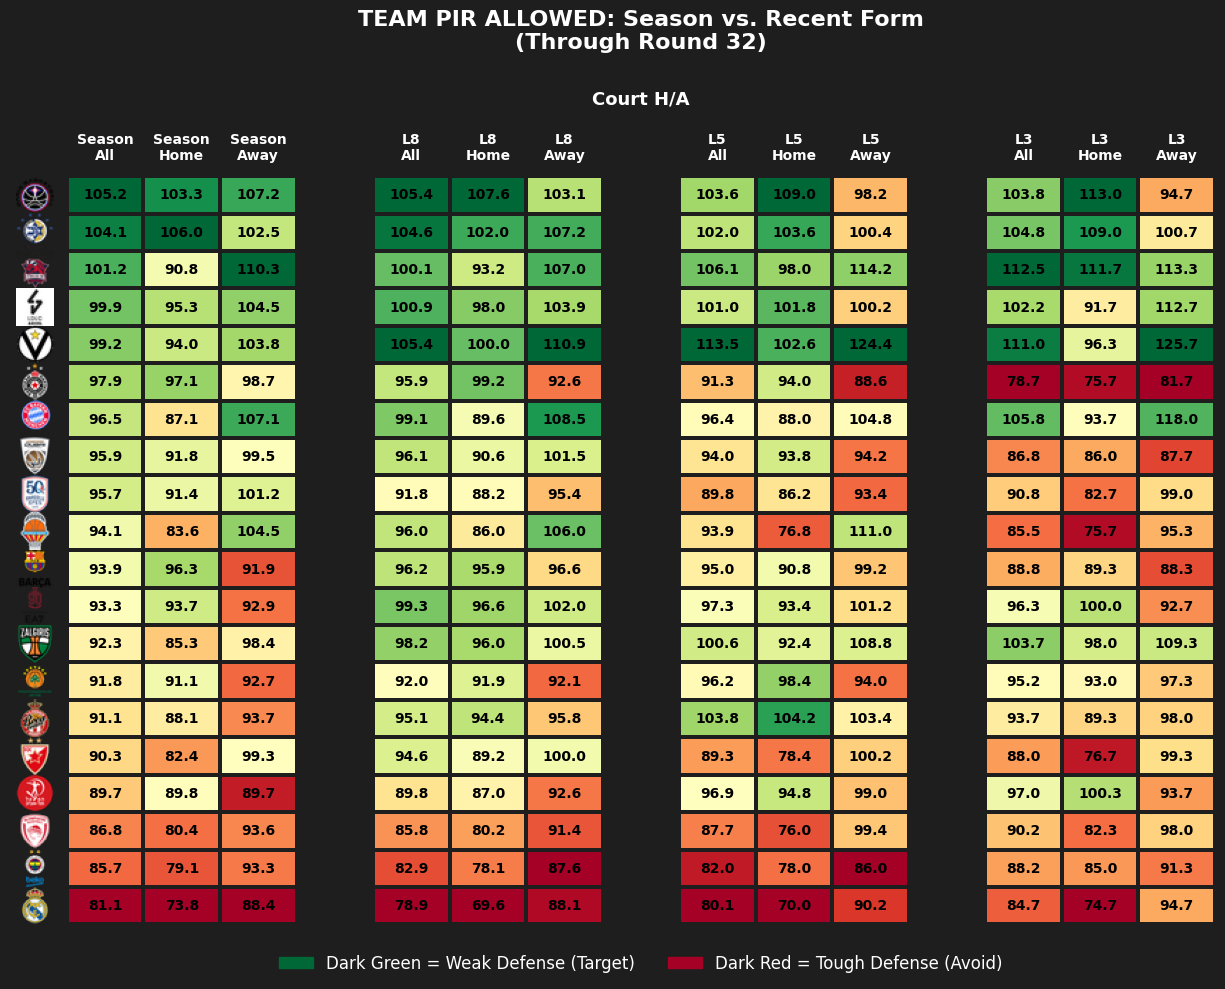

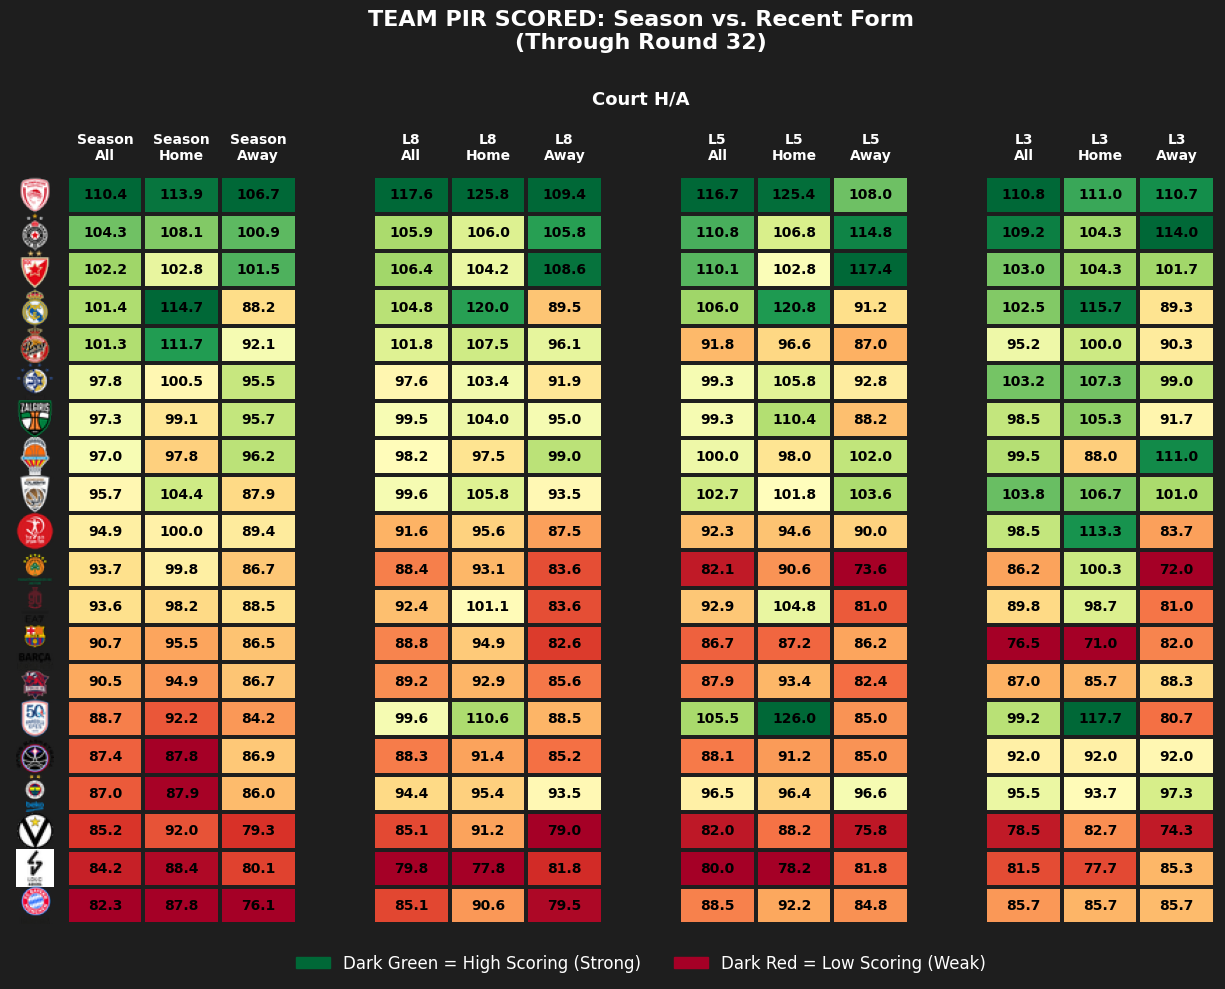

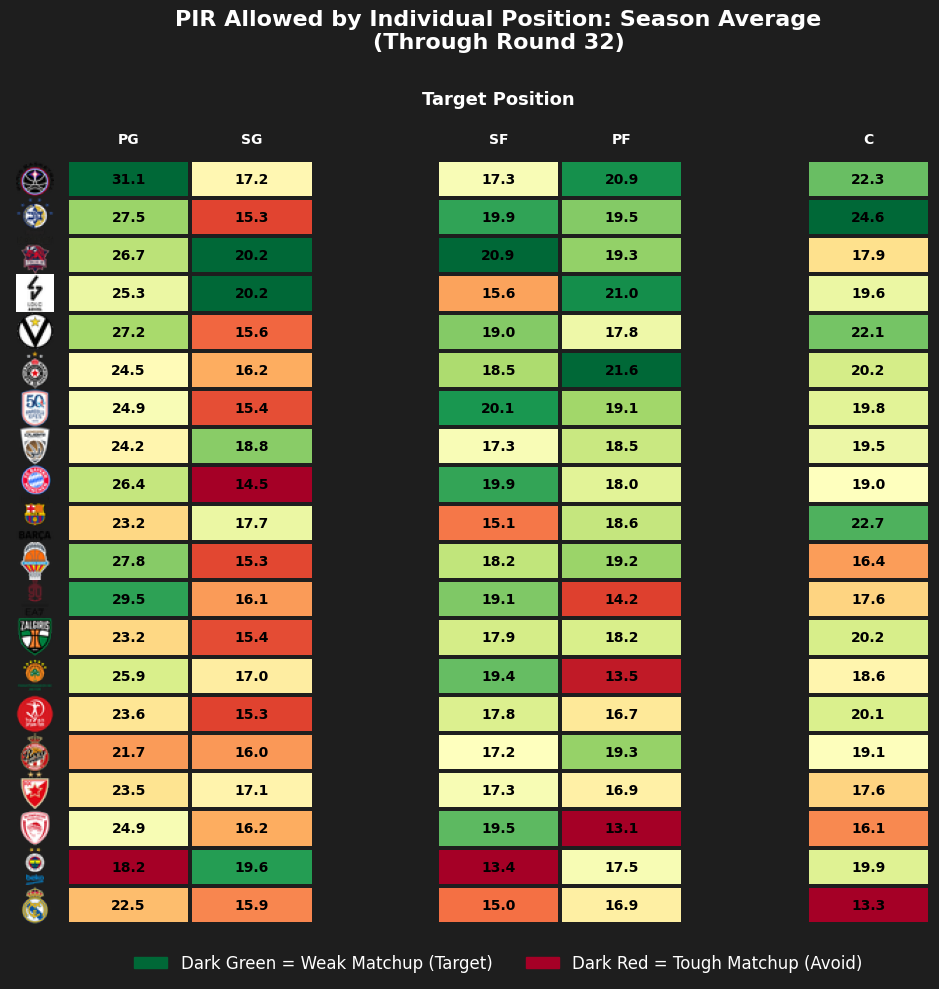

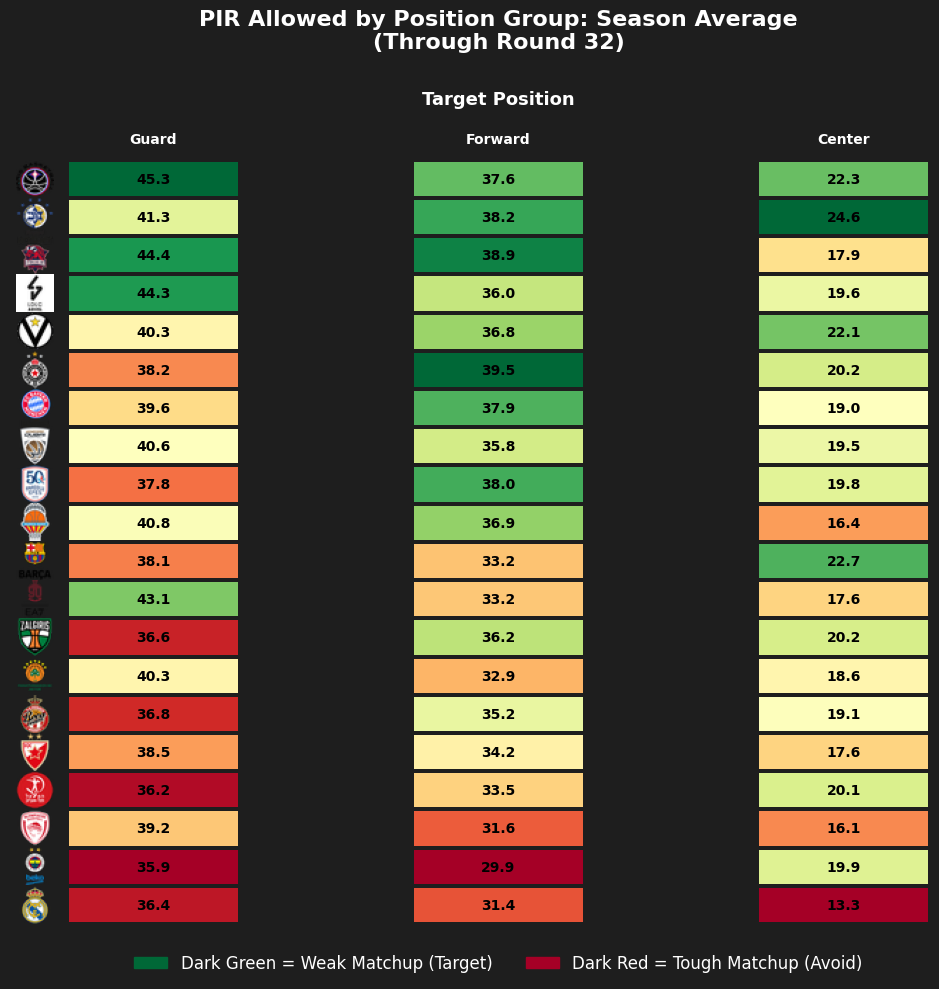

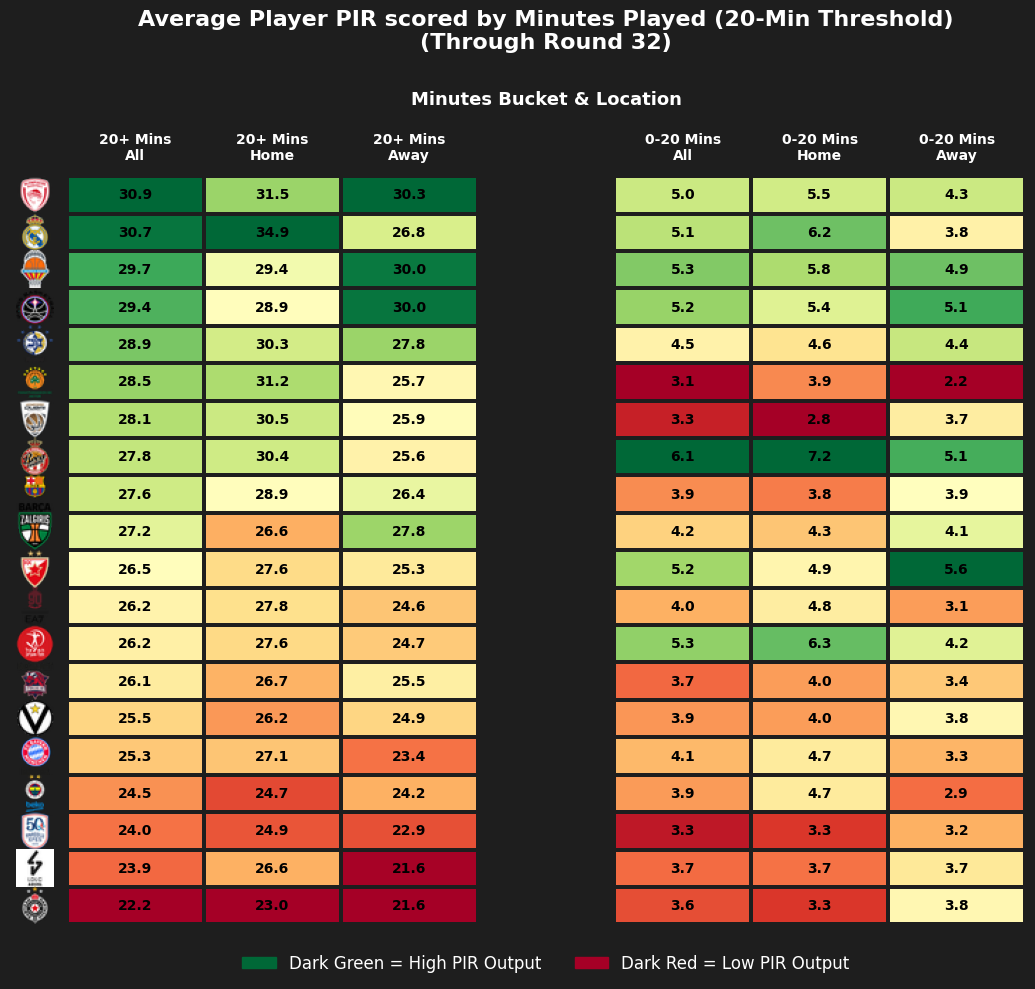

In [8]:
# Grab the latest round for the titles
LATEST_ROUND = dfseason['Round'].max()
LATEST_ROUND = 32   # Manually because the API pulled the preplayed game OLY vs PBB for Round 34 because they will not be able at the correct date.

# PIR Allowed: Form vs Season
generate_form_heatmap("data/PIR_Team_Analysis.csv", metric="PIR_Allowed", title_prefix="TEAM PIR ALLOWED", round_num=LATEST_ROUND)

# PIR Scored: Form vs Season
generate_form_heatmap("data/PIR_Team_Analysis.csv", metric="PIR_Scored", title_prefix="TEAM PIR SCORED", round_num=LATEST_ROUND)

# Position Analysis (5-way: PG, SG, SF, PF, C)
generate_position_heatmap("data/PIR_Team_Analysis.csv", group_type="5-way", round_num=LATEST_ROUND)

# Position Analysis (3-way: Guard, Forward, Center)
generate_position_heatmap("data/PIR_Team_Analysis.csv", group_type="3-way", round_num=LATEST_ROUND)

# Player Minutes Analysis (20-minute threshold)
generate_minutes_heatmap(dfseason, threshold=20, round_num=LATEST_ROUND)